# Principal Component Analysis

High-dimensional data is hard to visualize and expensive to work with — yet often the data really lives on a much lower-dimensional subspace. **Principal Component Analysis (PCA)** finds that subspace: it rotates the coordinate system so that the first axis points along the direction of greatest variance in the data, the second along the next-greatest (orthogonal to the first), and so on. Keeping only the first $M$ of these axes gives a compact, lower-dimensional representation that preserves as much of the data's spread as possible.

**This notebook covers:**
1. **Standardizing** the data so every feature is on a comparable scale.
2. Implementing PCA from scratch via the **eigendecomposition of the covariance matrix**.
3. Applying it to a 2-D toy data set to *see* the principal components (eigenvectors).
4. Applying it to the **MNIST** images: measuring the **reconstruction error** as a function of the number of components, and inspecting reconstructed digits for different amounts of *explained variance*.

## Imports

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, fixed
from sklearn.datasets import fetch_openml

## The Datasets

In this notebook we use two datasets:
- a two-dimensional **toy dataset**, small enough to plot the principal components directly, and
- the image dataset [MNIST](https://www.openml.org/d/554) of hand-written digits.

We collect $N$ samples into a matrix $\mathbf{X} \in \mathbb{R}^{N \times D}$, where the $n$-th **row** is the $n$-th sample — a $D$-dimensional feature vector $\mathbf{x}_n = (x_{n1}, \dots, x_{nD})^\mathrm{T}$. For MNIST each $28 \times 28$ image is flattened into a $D = 784$ dimensional vector.

> Below, we generate the toy dataset, download MNIST, and visualize both. (The first download of MNIST may take a moment.)

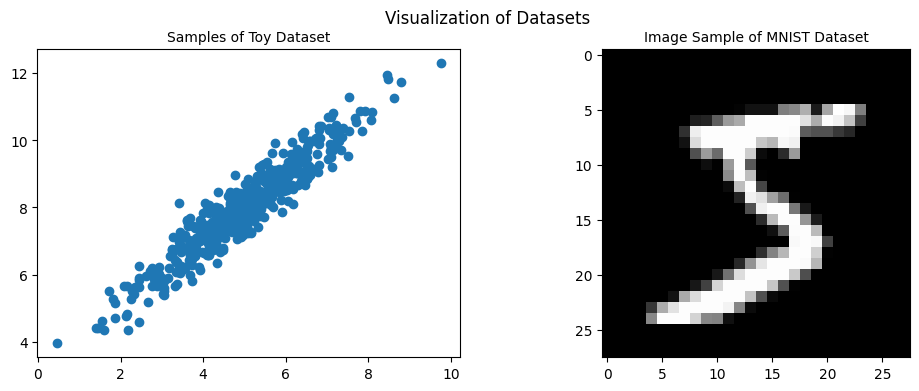

In [96]:
# Generate the 2D toy dataset (correlated Gaussian).
X_toy = np.random.RandomState(42).multivariate_normal(mean=[5, 8], cov=[[2, 1.9], [1.9, 2]], size=500)

# Download the MNIST dataset.
X_img, y_img = fetch_openml('mnist_784', version=1, return_X_y=True)
X_img = X_img.values
y_img = y_img.values

# Plot both datasets.
fig = plt.figure(figsize=(12, 4))
fig.suptitle('Visualization of Datasets')
plt.subplot(121)
plt.title('Samples of Toy Dataset', fontsize=10)
plt.scatter(X_toy[:, 0], X_toy[:, 1])
plt.subplot(122)
plt.title('Image Sample of MNIST Dataset', fontsize=10)
plt.imshow(X_img[0].reshape(28, 28), cmap='gray')
plt.show()

## Standardization

Before applying PCA we **standardize** the data. Each feature value $x_{*d}$ of a sample $\mathbf{x}_*$ is rescaled as
$$x_{*d} \leftarrow \frac{x_{*d} - \mu_d}{\sigma_d},$$
where $\mu_d$ and $\sigma_d > 0$ are the **mean** and **standard deviation** of the $d$-th feature, computed on the training set $\mathbf{X}$. After this transform every feature has **zero mean and unit variance**. This is also known as [feature scaling or data normalization](https://en.wikipedia.org/wiki/Feature_scaling).

PCA looks for directions of large variance, so a feature measured on a large numerical scale would dominate purely because of its units. Standardization removes that bias by putting all features on equal footing.

> **Implement the `StandardScaler` class below**: `fit` stores the per-feature mean and standard deviation, `transform` standardizes new data, and `inverse_transform` undoes it.

**Python note — the `1e-10` term:** some features can have zero standard deviation (e.g. the always-black border pixels of MNIST). Adding a tiny constant to $\sigma$ avoids dividing by zero.

In [97]:
class StandardScaler:
    """Standardize features by removing the mean and scaling to unit variance."""

    def fit(self, X):
        """Determine the parameters needed to standardize the data.

        Args:
            X (array-like): Input samples.

        Returns:
            The fitted StandardScaler object.
        """
####################
# Your Code Here   #
####################
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0)
        return self

    def transform(self, X):
        """Standardize the input samples `X`.

        Args:
            X (array-like): Input samples.

        Returns:
            Standardized samples.
        """
####################
# Your Code Here   #
####################
        return (X - self.mean_) / self.scale_

    def inverse_transform(self, Z):
        """Scale standardized data back to the original representation.

        Args:
            Z (array-like): Standardized samples.

        Returns:
            Re-scaled samples.
        """
####################
# Your Code Here   #
####################
        return Z * self.scale_ + self.mean_

> **Standardize both datasets and visualize the result.** The standardized toy data should be centered at the origin; the standardized digit looks noisier because rarely-active pixels get amplified.

/var/folders/_1/n85hbfgd2j93hh10__cjmgh40000gn/T/ipykernel_7093/1019836257.py:32: RuntimeWarning: invalid value encountered in divide
  return (X - self.mean_) / self.scale_


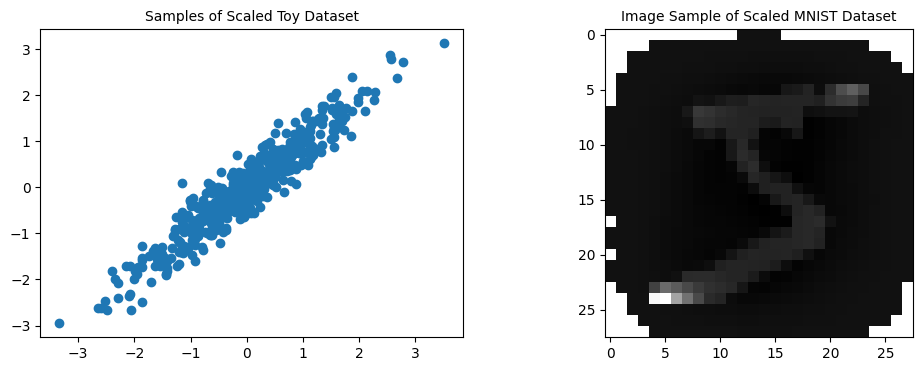

In [98]:
####################
# Your Code Here   #
####################
scaler = StandardScaler()
scaler.fit(X_toy)
X_toy_scaled = scaler.transform(X_toy)

scaler.fit(X_img)
X_img_scaled = scaler.transform(X_img)

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.title('Samples of Scaled Toy Dataset', fontsize=10)
plt.scatter(X_toy_scaled[:, 0], X_toy_scaled[:, 1])
plt.subplot(122)
plt.title('Image Sample of Scaled MNIST Dataset', fontsize=10)
plt.imshow(X_img_scaled[0].reshape(28, 28), cmap='gray')


#### Question
Why should we standardize the data before applying PCA?

Because PCA is sensitive to the scale of the features, and standardization ensures that all features contribute equally to the analysis by having zero mean and unit variance.

## PCA on the Toy Dataset

We now implement PCA for a training set $\mathbf{X}$ with mean $\boldsymbol{\mu} \in \mathbb{R}^D$ (which is $\mathbf{0}$ if $\mathbf{X}$ was standardized), reducing samples from $D$ dimensions to $M \le D$ dimensions. The algorithm has four steps:

1. **Center** the data by subtracting the mean $\boldsymbol{\mu}$.
2. **Covariance matrix:** compute the $D \times D$ matrix $\;\mathbf{S} = \frac{1}{N}\sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu})(\mathbf{x}_n - \boldsymbol{\mu})^\mathrm{T}.$
3. **Eigendecomposition:** find eigenvalues $\lambda_i$ and eigenvectors $\mathbf{u}_i$ of $\mathbf{S}$. Each eigenvector is a **principal component** (a direction), and its eigenvalue is the **variance of the data along that direction**. Sort them in *decreasing* order of $\lambda_i$.
4. **Projection:** stack the top $M$ eigenvectors as columns of $\mathbf{B} = (\mathbf{u}_1, \dots, \mathbf{u}_M) \in \mathbb{R}^{D \times M}$. To project a centered sample $\mathbf{x} - \boldsymbol{\mu}$ onto this subspace, we measure how far it reaches along each principal direction by taking an **inner product** with each basis vector: the $j$-th coordinate is
$$z_j = \mathbf{u}_j^\mathrm{T}(\mathbf{x} - \boldsymbol{\mu}).$$
Stacking these $M$ coordinates gives the low-dimensional representation $\mathbf{z} = \mathbf{B}^\mathrm{T}(\mathbf{x} - \boldsymbol{\mu}) \in \mathbb{R}^M$. To **reconstruct**, we place those coordinates back onto their directions and add the mean: $\tilde{\mathbf{x}} = \mathbf{B}\mathbf{z} + \boldsymbol{\mu} = \sum_{j=1}^{M} z_j\,\mathbf{u}_j + \boldsymbol{\mu}$. Because we keep only $M < D$ directions, $\tilde{\mathbf{x}}$ is the closest point to $\mathbf{x}$ that lies inside the subspace.

**Choosing $M$ via explained variance.** A common rule sets a threshold $c \in (0, 1]$ and keeps the fewest components whose cumulative variance reaches it:
$$M_c = \arg\min_{M \in \{1, \dots, D\}} M \quad \text{s.t.} \quad \frac{\sum_{j=1}^{M} \lambda_{j}}{\sum_{l=1}^{D} \lambda_{l}} \geq c.$$

> **Implement the `PCA` class below.** If `n_components` $\ge 1$ it is the integer number of components to keep; if `0 < n_components < 1` it is the explained-variance threshold $c$, and `_determine_M` should pick $M$ accordingly.

**Python note — `np.linalg.eigh`:** the covariance matrix is symmetric, so we use `eigh` (not `eig`). It returns real eigenvalues in *ascending* order with orthonormal eigenvectors as the **columns** of `U_`.

In [ ]:
class PCA:
    """Principal component analysis for N >= D, where N is the number of
    samples and D is the number of features.

    Args:
        n_components (int, float): If `n_components >= 1`, the dimension is reduced
            from D to `n_components`. If `0 < n_components < 1`, the number of
            components is chosen so that at least this fraction of the variance
            is explained.
    """
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        """Determine the parameters of the PCA.

        Args:
            X (array-like): Input samples.

        Returns:
            The fitted PCA object.
        """
        mean = np.mean(X, axis=0)
        X_centered = X - mean
        cov_matrix = np.cov(X_centered, rowvar=False)
        self.eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        self.sorted_indices = np.argsort(self.eigenvalues)[::-1]
        M = self._determine_M(X)
        self.components_ = eigenvectors[:, self.sorted_indices[:M]]
        self.mean_ = mean
        return self

    def transform(self, X):
        """Project samples from the D-dimensional input space into the
        M-dimensional projection space.

        Args:
            X (array-like): Samples in the input space.

        Returns:
            Transformed samples in the projection space.
        """
        return (X - self.mean_) @ self.components_

    def inverse_transform(self, Z):
        """Map samples from the M-dimensional projection space back into the
        D-dimensional input space.

        Args:
            Z (array-like): Samples in the projection space.

        Returns:
            Re-transformed samples in the input space.
        """
        return Z @ self.components_.T + self.mean_

    def _determine_M(self, X):
        """Determine the number of selected components M."""
        if 0 < self.n_components < 1:
            # \frac{\sum_{j=1}^{M} \lambda_{j}}{\sum_{l=1}^{D} \lambda_{l}} \geq c.$$
            cumulative_variance = np.cumsum(self.eigenvalues[self.sorted_indices]) / np.sum(self.eigenvalues)
            M = np.searchsorted(cumulative_variance, self.n_components) + 1
            print(f"Selected number of components M: {M} to explain at least {self.n_components*100}% of the variance.")
            print(f"Cumulative variance explained by {M} components: {cumulative_variance[M-1]*100:.2f}%")
            return M
        else:
            return int(self.n_components)

> **Apply the PCA to the toy data set** with $M = 1$ to visualize the eigenvectors and the reconstruction.

**What to look for:**
- The two arrows are the eigenvectors, each scaled by $3\sqrt{\lambda_i}$ — the **longer** arrow points along the direction of greatest variance (the first principal component).
- With $M = 1$ we keep only that first direction, so the **reconstructed samples collapse onto a single line** — the best 1-D summary of the 2-D cloud.

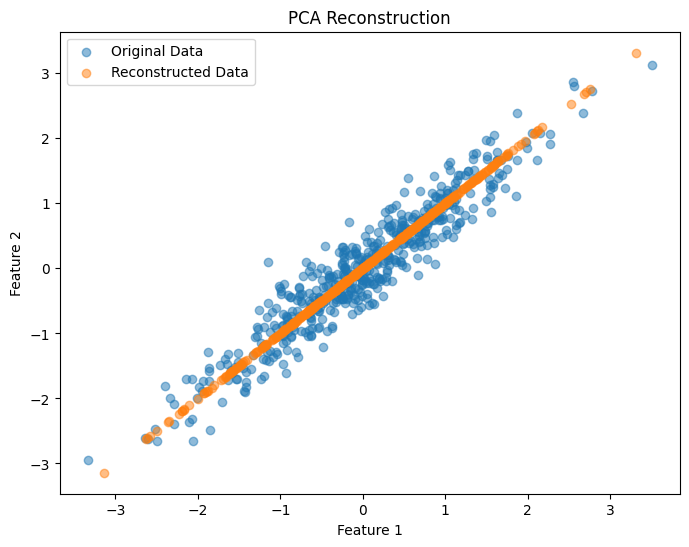

In [100]:
####################
# Your Code Here   #
####################

pca = PCA(n_components=1)

pca.fit(X_toy_scaled)
X_pca = pca.transform(X_toy_scaled)
X_reconstructed = pca.inverse_transform(X_pca)

assert X_reconstructed.shape == X_toy_scaled.shape, "Reconstructed data should have the same shape as the original data."

plt.figure(figsize=(8, 6))
plt.scatter(X_toy_scaled[:, 0], X_toy_scaled[:, 1], alpha=0.5, label='Original Data')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.5, label='Reconstructed Data')
plt.title('PCA Reconstruction')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## PCA on the Image Data Set

We now study how the number of selected components $M$ affects the quality of the reconstruction on MNIST. We measure quality with the **reconstruction error** (the mean squared error between original and reconstructed samples):
$$J = \frac{1}{N} \sum_{n=1}^{N} \lVert \mathbf{x}_n - \tilde{\mathbf{x}}_{n} \rVert^2.$$

> **Implement the function below** to compute this reconstruction error.

In [101]:
def compute_reconstruction_error(X_orig, X_rec):
    """Compute the reconstruction error (mean squared error).

    Args:
        X_orig (array-like): Original samples.
        X_rec (array-like): Reconstructed samples.

    Returns:
        Reconstruction error.
    """
    return 1/len(X_orig) * np.sum((X_orig - X_rec) ** 2)

> **Compute the reconstruction error as a function of the number of components $M$.**

**What to look for:** the error decreases as $M$ grows and reaches (almost) zero once $M = D$, since we then keep every direction. The curve typically drops steeply at first — a sign that a small number of components already captures most of the variance.

In [102]:
compute_reconstruction_error(X_toy_scaled, X_reconstructed)

np.float64(0.05250910989592093)

> **Finally, inspect the reconstructions qualitatively.** The interactive widget below reconstructs a chosen digit for increasing amounts of explained variance $c$. Drag the `image_idx` slider to try different digits.

**What to look for:** at a low explained variance the reconstruction is blurry and generic; as $c$ increases more components are used (larger $M$), and the digit becomes progressively sharper and closer to the original.

In [ ]:
# slider for n_components in interactive figure
def plot_reconstruction_error(n_components, X):
    pca = PCA(n_components=n_components)
    pca.fit(X)
    X_pca = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    error = compute_reconstruction_error(X, X_reconstructed)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Original Data')
    plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.5, label='Reconstructed Data')
    plt.title(f'PCA Reconstruction with n_components={n_components}\nReconstruction Error: {error:.4f}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

interact(plot_reconstruction_error, n_components=(1, 2, 1), X=fixed(X_toy_scaled))

interact(plot_reconstruction_error, n_components=(0.0, 1.0, 0.01), X=fixed(X_toy_scaled))


interactive(children=(IntSlider(value=1, description='n_components', max=2, min=1), Output()), _dom_classes=('…

interactive(children=(FloatSlider(value=0.5, description='n_components', max=1.0, step=0.01), Output()), _dom_…

<function __main__.plot_reconstruction_error(n_components, X)>